<a href="https://colab.research.google.com/github/Tanuja781/Forest-cover-Type-Classicifier/blob/main/Forest_Cover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
df = pd.read_csv("/content/covtype.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234             238   

Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64
Missing values in Cover_Type:
0
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Ty

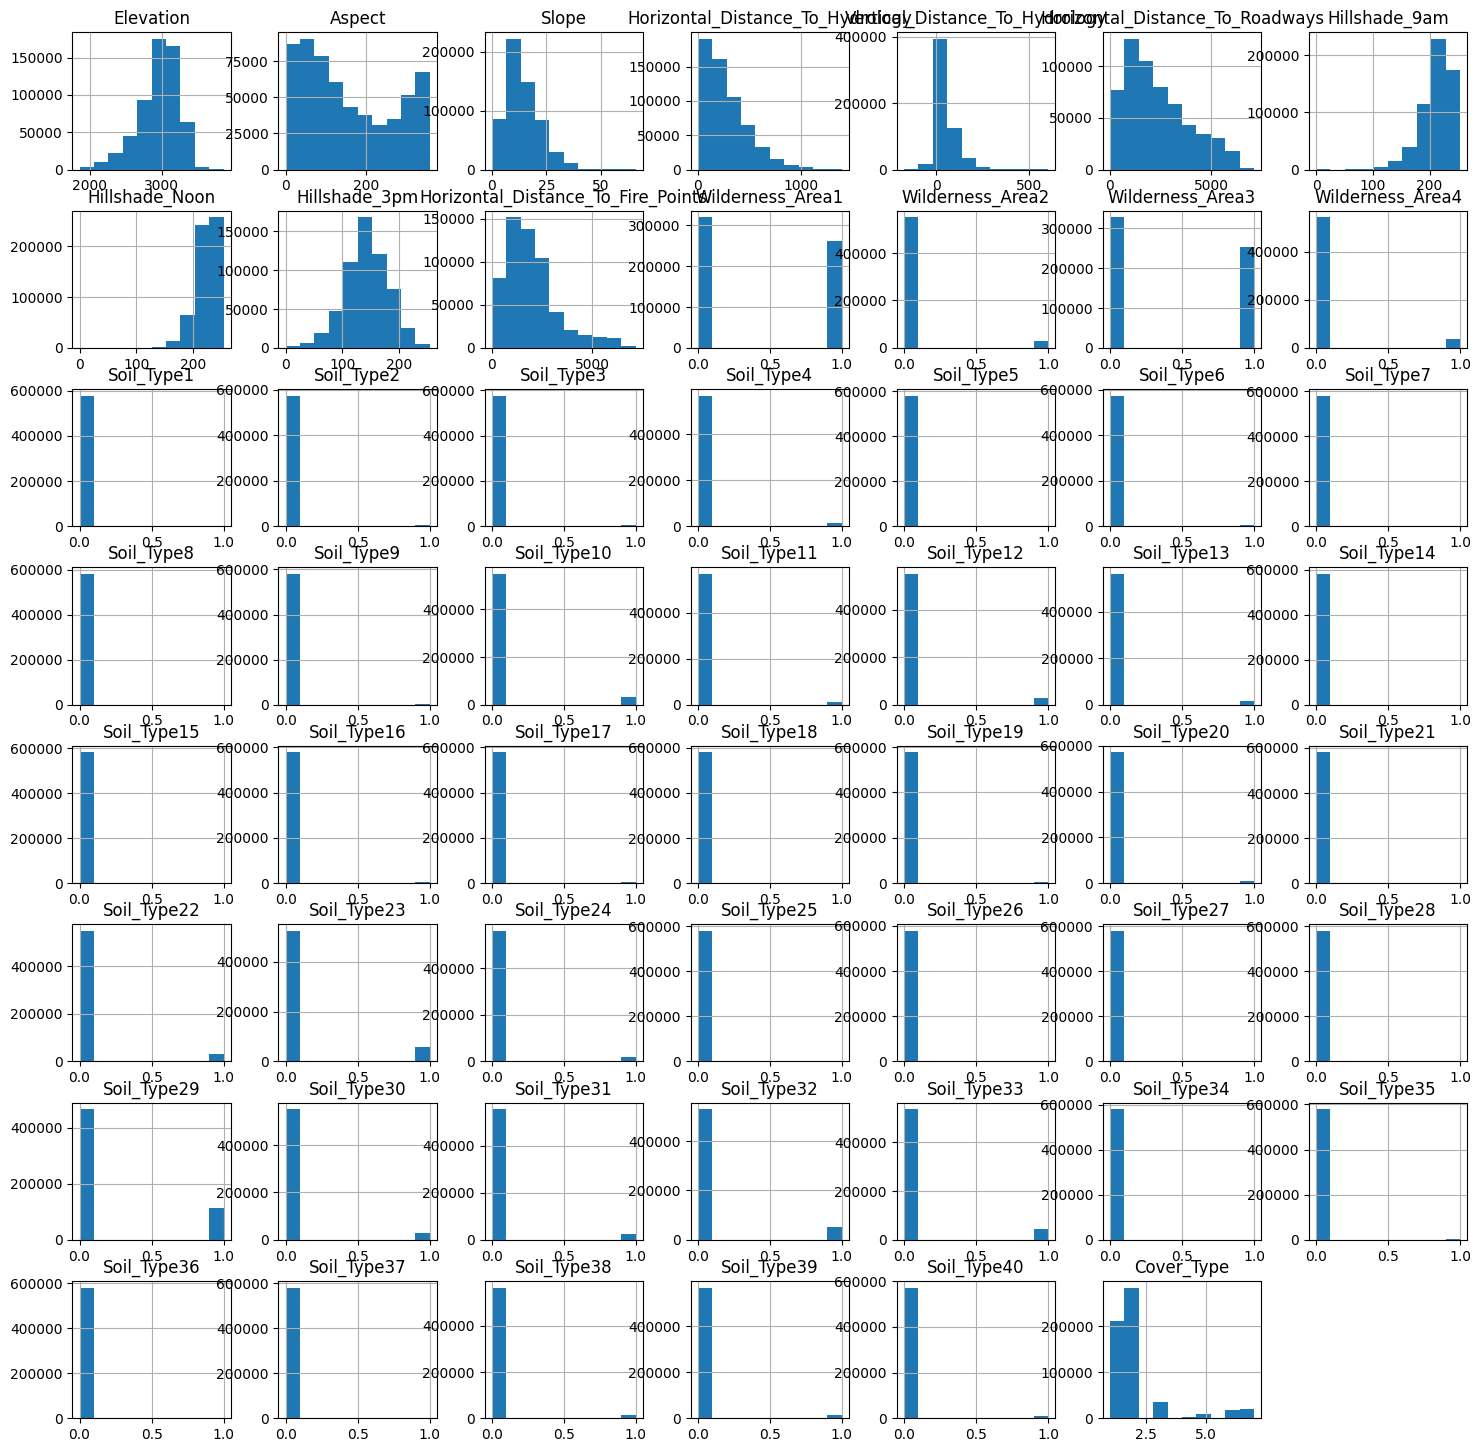

                                    Elevation    Aspect     Slope  \
Elevation                            1.000000  0.015735 -0.242697   
Aspect                               0.015735  1.000000  0.078728   
Slope                               -0.242697  0.078728  1.000000   
Horizontal_Distance_To_Hydrology     0.306229  0.017376 -0.010607   
Vertical_Distance_To_Hydrology       0.093306  0.070305  0.274976   
Horizontal_Distance_To_Roadways      0.365559  0.025121 -0.215914   
Hillshade_9am                        0.112179 -0.579273 -0.327199   
Hillshade_Noon                       0.205887  0.336103 -0.526911   
Hillshade_3pm                        0.059148  0.646944 -0.175854   
Horizontal_Distance_To_Fire_Points   0.148022 -0.109172 -0.185662   
Wilderness_Area1                     0.131838 -0.140123 -0.234576   
Wilderness_Area2                     0.238164  0.055988 -0.036253   
Wilderness_Area3                     0.066550  0.074904  0.125663   
Wilderness_Area4                  

In [ ]:
print(df["Cover_Type"].value_counts())

print("Missing values in Cover_Type:")
print(df["Cover_Type"].isnull().sum())
print(df.isnull().sum())

print("Total Missing Values:")
print(df.isnull().sum().sum())
df.hist(figsize=(18,18))
plt.show()
print(df.corr())


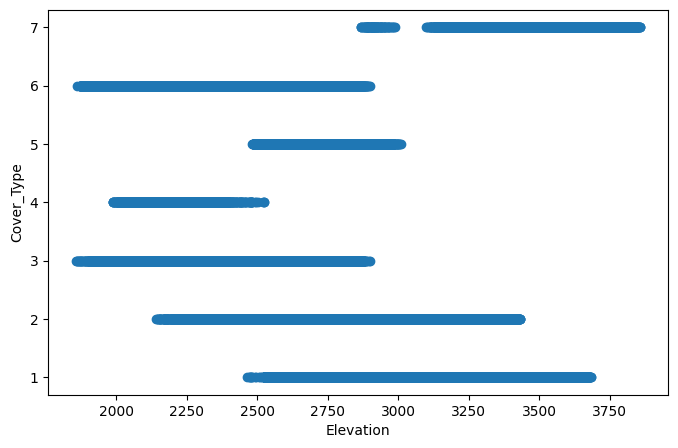

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Elevation"], df["Cover_Type"])
plt.xlabel("Elevation")
plt.ylabel("Cover_Type")
plt.show()

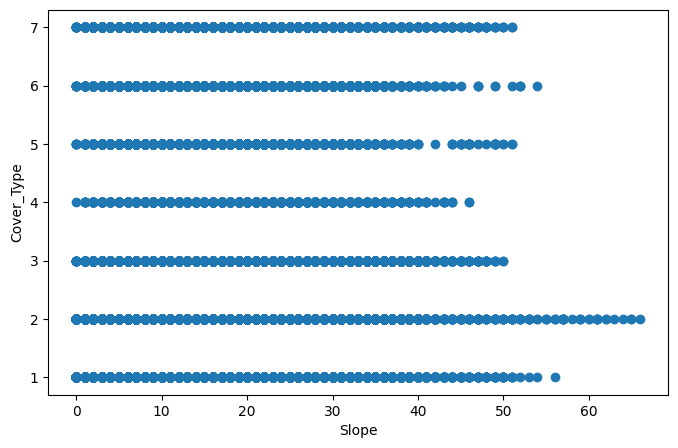

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Slope"], df["Cover_Type"])
plt.xlabel("Slope")
plt.ylabel("Cover_Type")
plt.show()

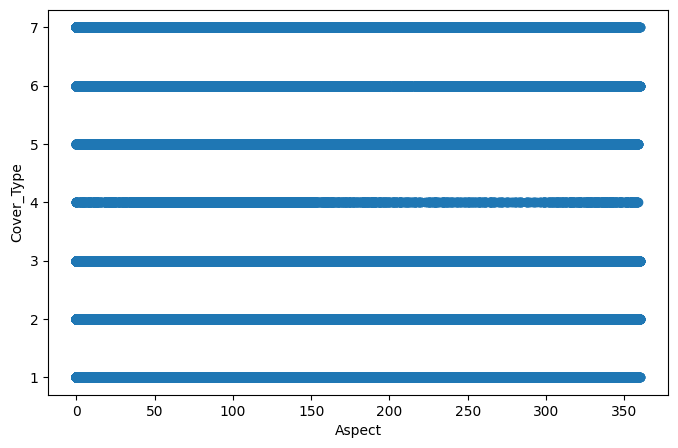

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Aspect"], df["Cover_Type"])
plt.xlabel("Aspect")
plt.ylabel("Cover_Type")
plt.show()

In [ ]:
X = df.drop("Cover_Type", axis=1)

y = df["Cover_Type"]

print(X.shape)
print(y.shape)

(581012, 54)
(581012,)


In [ ]:
print("NaN values in y:", y.isna().sum())

print("Total NaN values in X:", X.isna().sum().sum())

print(y.head())

print(y.tail())

print(y.dtype)
df = df.dropna(subset=["Cover_Type"])

X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

NaN values in y: 0
Total NaN values in X: 0
0    5
1    5
2    2
3    2
4    5
Name: Cover_Type, dtype: int64
581007    3
581008    3
581009    3
581010    3
581011    3
Name: Cover_Type, dtype: int64
int64
(464809, 54)
(116203, 54)
(464809,)
(116203,)


In [ ]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9533


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           1       0.96      0.94      0.95     42368
           2       0.95      0.97      0.96     56661
           3       0.94      0.96      0.95      7151
           4       0.92      0.86      0.89       549
           5       0.95      0.77      0.85      1899
           6       0.93      0.89      0.91      3473
           7       0.97      0.95      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.95      0.91      0.92    116203
weighted avg       0.95      0.95      0.95    116203


Confusion Matrix:

[[39889  2376     1     0     6     2    94]
 [ 1300 55120   104     1    54    68    14]
 [    0   122  6866    23     6   134     0]
 [    0     0    58   470     0    21     0]
 [   25   383    20     0  1462     9     0]
 [    5    92   261    19     4  3092     0]
 [  193    28     0     0     0     0  3881]]


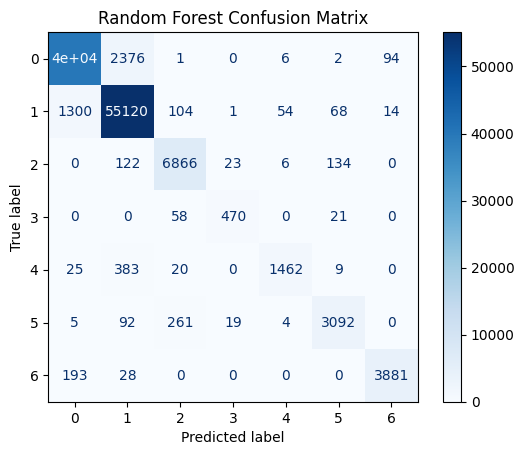

In [ ]:
# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

In [ ]:
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Model Accuracy: 0.925199865752175

Classification Report:

              precision    recall  f1-score   support

           1       0.95      0.89      0.92     42368
           2       0.91      0.96      0.93     56661
           3       0.93      0.95      0.94      7151
           4       0.92      0.84      0.88       549
           5       0.96      0.57      0.71      1899
           6       0.92      0.85      0.88      3473
           7       0.98      0.91      0.94      4102

    accuracy                           0.93    116203
   macro avg       0.94      0.85      0.89    116203
weighted avg       0.93      0.93      0.92    116203


Confusion Matrix:

[[37877  4399     4     0     6     5    77]
 [ 1751 54631   143     1    40    78    17]
 [    1   204  6770    22     0   154     0]
 [    0     0    73   459     0    17     0]
 [   22   769    20     0  1083     5     0]
 [    3   204   305    17     2  2942     0]
 [  330    23     0     0     0     0  3749]]


In [ ]:
baseline_accuracy = accuracy_score(y_test, y_pred)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Baseline Accuracy :", baseline_accuracy)
print("Tuned Accuracy    :", tuned_accuracy)

if tuned_accuracy > baseline_accuracy:
    print("\nThe tuned Random Forest model performed better.")
elif tuned_accuracy == baseline_accuracy:
    print("\nBoth models achieved the same accuracy.")
else:
    print("\nThe baseline Random Forest model performed better.")

Baseline Accuracy : 0.9533316695782381
Tuned Accuracy    : 0.925199865752175

The baseline Random Forest model performed better.


In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [ ]:
print("Gradient Boosting Accuracy:")
print(accuracy_score(y_test, gb_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)

print("Random Forest Accuracy :", rf_accuracy)
print("Gradient Boosting Accuracy :", gb_accuracy)

if rf_accuracy > gb_accuracy:
    print("Random Forest performed better.")
else:
    print("Gradient Boosting performed better.")
best_model = rf_model if rf_accuracy >= gb_accuracy else gb_model

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

In [ ]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
joblib.dump(best_model, "forest_cover_classifier.pkl")

print("Model saved successfully.")
loaded_model = joblib.load("forest_cover_classifier.pkl")

print("Model loaded successfully.")

In [ ]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Actual Class :", y_test.iloc[0])
print("Predicted Class :", prediction[0])

In [ ]:
sample_data = X_test.iloc[:5]

predictions = loaded_model.predict(sample_data)

results = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": predictions
})

results

In [ ]:
!git add . && !git commit -m "Updated project with new analysis" && !git push

In [ ]:
# Create README file in Colab
readme_content = """
# Forest Cover Type Classification

## Project Overview
This project aims to predict forest cover types from cartographic variables using machine learning.

## Dataset
- **Source**: UCI Machine Learning Repository
- **Samples**: 581,012
- **Features**: 54 (10 continuous, 44 binary)
- **Target**: 7 forest cover types

## Features
- Elevation, Aspect, Slope
- Distance to hydrology, roadways, fire points
- Hillshade indices
- Wilderness area codes (1-4)
- Soil type codes (1-40)

## Models Used
- Random Forest Classifier
- Logistic Regression
- XGBoost

## Results
- Random Forest Accuracy: ~95%

## How to Run
1. Install dependencies: `pip install -r requirements.txt`
2. Run: `python forest_cover_classification.py`

## Dependencies
- pandas
- numpy
- scikit-learn
- matplotlib
- seaborn
- xgboost

## Author
[Tanuja Patil]
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

!git add README.md
!git commit -m "Added README file"
!git push